# 01 — Análise Exploratória de Dados

## Predição de Aprovação de Pedidos de Cartão de Crédito utilizando Machine Learning

---

### Objetivo do projeto

O objetivo deste projeto é desenvolver uma solução de **Machine Learning supervisionado**
capaz de identificar perfis de **bons e maus pagadores**, utilizando informações
pessoais, financeiras e cadastrais dos solicitantes.


## 1 - Carregamento das bases

- `application_record.csv`: contém informações cadastrais, pessoais e financeiras dos clientes;
- `credit_record.csv`: contém o histórico mensal relacionado ao comportamento de crédito.


In [35]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import sys
import os
from pathlib import Path

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

#if str(ROOT) not in sys.path:
#    sys.path.insert(0, str(ROOT))

pd.set_option("display.max_columns", None)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [62]:
from src import config, data, evaluation, models, preprocessing, visualization

In [4]:
application_original, credit_original = data.load_raw()

# Base cadastral dos clientes.
application = application_original.copy()

# Base contendo o histórico mensal de crédito.
credit = credit_original.copy()

## 2 - Visão geral
### 2.1 - Dados **application**

_Dimensões, tipos e primeira impressão do dataset._

In [5]:
print('Application:',application.shape)
application.head()

Application: (438557, 18)


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


In [6]:
application.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  object 
 2   FLAG_OWN_CAR         438557 non-null  object 
 3   FLAG_OWN_REALTY      438557 non-null  object 
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  object 
 7   NAME_EDUCATION_TYPE  438557 non-null  object 
 8   NAME_FAMILY_STATUS   438557 non-null  object 
 9   NAME_HOUSING_TYPE    438557 non-null  object 
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-null  int64  
 15  FLAG_EMAIL       

Separação das variaveis numéricas das variáveis categóricas

In [8]:
print('Tipos das variáveis - APPLICATION')
display(application.dtypes.to_frame(name='Tipo'))

Tipos das variáveis - APPLICATION


,Tipo
ID,int64
CODE_GENDER,object
FLAG_OWN_CAR,object
FLAG_OWN_REALTY,object
CNT_CHILDREN,int64
AMT_INCOME_TOTAL,float64
NAME_INCOME_TYPE,object
NAME_EDUCATION_TYPE,object
NAME_FAMILY_STATUS,object
NAME_HOUSING_TYPE,object


In [9]:
nulos_application = application.isna().sum()
percentual_nulos_application = (application.isna().mean() * 100).round(2)
tabela_nulos_application = pd.DataFrame({'Quantidade_Nulos': nulos_application,'Percentual_Nulos': percentual_nulos_application})
tabela_nulos_application.sort_values(by='Quantidade_Nulos', ascending=False)

,Quantidade_Nulos,Percentual_Nulos
OCCUPATION_TYPE,134203,30.6
ID,0,0.0
CODE_GENDER,0,0.0
FLAG_OWN_CAR,0,0.0
CNT_CHILDREN,0,0.0
FLAG_OWN_REALTY,0,0.0
NAME_INCOME_TYPE,0,0.0
NAME_EDUCATION_TYPE,0,0.0
NAME_FAMILY_STATUS,0,0.0
AMT_INCOME_TOTAL,0,0.0


In [34]:
application.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,438557.0,6.022176e+06,571637.023257,5.008804e+06,5.609375e+06,6.047745e+06,6.456971e+06,7.999952e+06
CNT_CHILDREN,438557.0,4.273903e-01,0.724882,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.900000e+01
AMT_INCOME_TOTAL,438557.0,1.875243e+05,110086.853066,2.610000e+04,1.215000e+05,1.607805e+05,2.250000e+05,6.750000e+06
DAYS_BIRTH,438557.0,-1.599790e+04,4185.030007,-2.520100e+04,-1.948300e+04,-1.563000e+04,-1.251400e+04,-7.489000e+03
DAYS_EMPLOYED,438557.0,6.056368e+04,138767.799647,-1.753100e+04,-3.103000e+03,-1.467000e+03,-3.710000e+02,3.652430e+05
FLAG_MOBIL,438557.0,1.000000e+00,0.000000,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
FLAG_WORK_PHONE,438557.0,2.061328e-01,0.404527,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
FLAG_PHONE,438557.0,2.877710e-01,0.452724,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00
FLAG_EMAIL,438557.0,1.082071e-01,0.310642,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
CNT_FAM_MEMBERS,438557.0,2.194465e+00,0.897207,1.000000e+00,2.000000e+00,2.000000e+00,3.000000e+00,2.000000e+01


A variável *DAYS_EMPLOYED* apresenta um número máximo equivalente a 1000 anos. Pelo dicionário de dados, números negativos seriam a quantidade de dias empregados e números positivos seriam a quantidade de dias desempregados. Separando os números positivos temos:

In [13]:
print('valores únicos de DAYS_EMPLOYED')
unemployed = application[application['DAYS_EMPLOYED'] > 0]
display(unemployed['DAYS_EMPLOYED'].value_counts(dropna=False))

valores únicos de DAYS_EMPLOYED


DAYS_EMPLOYED
365243    75329
Name: count, dtype: int64

In [14]:
print('valores únicos de OCCUPATION_TYPE para os casos de valores positivos em DAYS_EMPLOYED')
display(unemployed['OCCUPATION_TYPE'].value_counts(dropna=False))

valores únicos de OCCUPATION_TYPE para os casos de valores positivos em DAYS_EMPLOYED


OCCUPATION_TYPE
NaN    75329
Name: count, dtype: int64

Considerações sobre os valores positivos de DAYS_EMPLOYED:  
- todos os valores maiores que 0 são o mesmo número e esse número é inválido para dias desempregado por representar 1000 anos.  
- Todos os 75.329 registros de DAYS_EMPLOYED positivo apresentam OCCUPATION_TYPE nulo, mas não representa a totalidade do OCCUPATION_TYPE nulo (134.203 registros nulos).  


Decisão: Substituir os valores positivos de DAYS_EMPLOYED por 0 e o OCCUPATION_TYPE por .

In [15]:
# Apresentação da distribuição atual
display(application['OCCUPATION_TYPE'].value_counts(dropna=False))

OCCUPATION_TYPE
NaN                      134203
Laborers                  78240
Core staff                43007
Sales staff               41098
Managers                  35487
Drivers                   26090
High skill tech staff     17289
Accountants               15985
Medicine staff            13520
Cooking staff              8076
Security staff             7993
Cleaning staff             5845
Private service staff      3456
Low-skill Laborers         2140
Secretaries                2044
Waiters/barmen staff       1665
Realty agents              1041
HR staff                    774
IT staff                    604
Name: count, dtype: int64

In [16]:
# 1. Onde a ocupação é nula E os dias trabalhados são >= 0 (anomalia), preenche com 'Unemployed'
mask_unemployed = application['OCCUPATION_TYPE'].isna() & (application['DAYS_EMPLOYED'] >= 0)
application.loc[mask_unemployed, 'OCCUPATION_TYPE'] = 'Unemployed'

Informação mais fácil de compreender para **DAYS_BIRTH** e **DAYS_EMPLOYED**

In [44]:
# Idade em anos
application['IDADE_ANOS'] = (
    - application['DAYS_BIRTH']
    / 365.25).round(0).astype(int)

# Conversão do tempo de emprego em anos

application['ANOS_EMPREGO'] = (
    application['DAYS_EMPLOYED']
    .where(application['DAYS_EMPLOYED'] < 0)
    .abs()
    .div(365.25)
    .apply(np.floor)
    .astype('Int64')
)


In [33]:
valores_unicos_application = (application.nunique(dropna=False).sort_values())
display(valores_unicos_application.to_frame(name='Quantidade_Valores_Unicos'))

,Quantidade_Valores_Unicos
FLAG_MOBIL,1
CODE_GENDER,2
FLAG_OWN_REALTY,2
FLAG_OWN_CAR,2
FLAG_PHONE,2
FLAG_WORK_PHONE,2
FLAG_EMAIL,2
NAME_EDUCATION_TYPE,5
NAME_FAMILY_STATUS,5
NAME_INCOME_TYPE,5


In [19]:
total_application = len(application)
# retorna quantos valores diferentes existem
ids_unicos_application = application['ID'].nunique()
print('APPLICATION_RECORD')
print('Total de registros:', total_application)
print('IDs únicos:', ids_unicos_application)

APPLICATION_RECORD
Total de registros: 438557
IDs únicos: 438510


In [20]:
# Verificar se todas as colunas são exatamente iguais.
linhas_duplicadas_application = (application.duplicated().sum())
print('Linhas totalmente duplicadas em application:',linhas_duplicadas_application)


Linhas totalmente duplicadas em application: 0


In [21]:
# Buscar Ids repetidos.
ids_duplicados_application = (application.duplicated(subset='ID').sum())

print('Ocorrências adicionais de IDs:',ids_duplicados_application)

Ocorrências adicionais de IDs: 47


In [22]:
registros_ids_duplicados = (application[application.duplicated(subset='ID',keep=False)].sort_values('ID'))

display(registros_ids_duplicados)

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
425023,7022197,F,N,Y,0,450000.0,Commercial associate,Higher education,Separated,House / apartment,-19813,-1799,1,0,0,1,NaN,1.0
426818,7022197,M,Y,Y,3,135000.0,Working,Secondary / secondary special,Married,House / apartment,-11945,-735,1,0,0,1,Laborers,5.0
431911,7022327,M,Y,Y,0,256500.0,Commercial associate,Higher education,Married,House / apartment,-21503,-1674,1,0,0,1,Core staff,2.0
431545,7022327,F,N,Y,0,135000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-14771,-5298,1,0,0,0,High skill tech staff,1.0
425486,7023108,M,Y,Y,1,67500.0,Working,Secondary / secondary special,Married,House / apartment,-15156,-1696,1,1,0,0,Core staff,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426563,7836711,F,N,Y,2,292500.0,Working,Higher education,Married,House / apartment,-13747,-4386,1,0,1,0,Accountants,4.0
428620,7836971,F,N,Y,0,103500.0,Working,Secondary / secondary special,Civil marriage,House / apartment,-13383,-2798,1,0,1,0,Sales staff,2.0
421464,7836971,M,Y,N,1,157500.0,Working,Secondary / secondary special,Married,House / apartment,-13771,-5520,1,0,0,0,NaN,3.0
422068,7838075,M,N,Y,0,337500.0,Commercial associate,Secondary / secondary special,Married,House / apartment,-18198,-1275,1,0,0,1,Drivers,2.0


In [26]:
58874/438557*100

13.424480740245851

### Considerações finais **base application**:
- Contém dados nulos:
  - OCCUPATION_TYPE com 13,42%
    - Decisão: Manter valores nulos para tratamento no pre-processamento e ajustada variável para apresentar o valor unemployed quando dias de empregado for positivo, conforme dicionário de dados.
- Variáveis constante:
  - FLAG_MOBIL: Todos clientes com um único registro. Avaliar excluir variável.
- Datas:
  - DAYS_BIRTH e DAYS_EMPLOYED: Números negativos, tratar e converter em anos.
    - DAYS_EMPLOYED: Número positivo extremamente alto, identificado tratar-se de valor especial ajustado para 0.
- Outras variávei:
  - CNT_CHILDREN e CNT_FAM_MEMBERS: 19 filhos e 20 membros da família - possível outlier ou erro. Avaliar se trata do mesmo ID e tratar se necessário.
- Tipos de variáveis:
  - **numéricas**: como renda, número de filhos e quantidade de membros da família;
  - **categóricas**: como gênero, escolaridade, tipo de renda e ocupação;
  - **indicadoras/binárias**: como posse de carro, imóvel, telefone e e-mail;
  - **identificadora**: representada pela coluna `ID`.
- Existência de **IDs repetidos**: A base cadastral possui 438.557 registros, mas apenas 438.510 IDs únicos. Essa diferença resulta em 47 ocorrências adicionais de ID.
  - Avaliar o motivo de existir IDs repetidos e dados distintos. Tratar se necessário.

### 2.2 - Dados **credit**

In [23]:
print('Credit:', credit.shape)
credit.head()

Credit: (1048575, 3)


,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


In [24]:
credit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   ID              1048575 non-null  int64 
 1   MONTHS_BALANCE  1048575 non-null  int64 
 2   STATUS          1048575 non-null  object
dtypes: int64(2), object(1)
memory usage: 24.0+ MB


In [25]:
print('\nTipos das variáveis - CREDIT')
display(credit.dtypes.to_frame(name='Tipo'))


Tipos das variáveis - CREDIT


,Tipo
ID,int64
MONTHS_BALANCE,int64
STATUS,object


In [25]:
tabela_nulos_credit = pd.DataFrame({'Quantidade_Nulos': credit.isna().sum(),'Percentual_Nulos': (credit.isna().mean() * 100).round(2)})

display(tabela_nulos_credit)

,Quantidade_Nulos,Percentual_Nulos
ID,0,0.0
MONTHS_BALANCE,0,0.0
STATUS,0,0.0


In [26]:
credit.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,1048575.0,5.068286e+06,46150.578505,5001711.0,5023644.0,5062104.0,5113856.0,5150487.0
MONTHS_BALANCE,1048575.0,-1.913700e+01,14.023498,-60.0,-29.0,-17.0,-7.0,0.0


In [33]:
print('Valores Únicos da variável STATUS')
display(credit['STATUS'].value_counts(dropna=False))

Valores Únicos da variável STATUS


C    442031
0    383120
X    209230
1     11090
5      1693
2       868
3       320
4       223
Name: STATUS, dtype: int64

In [27]:
tabela_nulos_credit = pd.DataFrame({'Quantidade_Nulos': credit.isna().sum(),'Percentual_Nulos': (credit.isna().mean() * 100).round(2)})

display(tabela_nulos_credit)

,Quantidade_Nulos,Percentual_Nulos
ID,0,0.0
MONTHS_BALANCE,0,0.0
STATUS,0,0.0


In [28]:
total_credit = len(credit)
ids_unicos_credit = credit['ID'].nunique()
print('\nCREDIT_RECORD')
print('Total de registros:', total_credit)
print('IDs únicos:', ids_unicos_credit)


CREDIT_RECORD
Total de registros: 1048575
IDs únicos: 45985


In [29]:
linhas_duplicadas_credit = (credit.duplicated().sum())
print('Linhas totalmente duplicadas em credit:',linhas_duplicadas_credit)

Linhas totalmente duplicadas em credit: 0


In [30]:
# Verifica se existe mais de um registro para o mesmo cliente no mesmo MONTHS_BALANCE.

duplicidade_id_mes = (credit.duplicated(subset=['ID','MONTHS_BALANCE']).sum())
print('Duplicidades ID + MONTHS_BALANCE:',duplicidade_id_mes)

Duplicidades ID + MONTHS_BALANCE: 0


### Entendendo a variável **STATUS**

- Variável "Status": Registra a situação de crédito do cliente em determinado período. Será utilizada para definir a target.
- Adotaremos uma representação binária:
  - 0 = Bom pagador
  - 1 = Mau pagador
- Valores maiores representam situações
progressivamente mais graves de atraso:
  - 0 → 1 → 2 → 3 → 4 → 5
- Os códigos "C" e "X" não representam atraso, mas também não possuem
exatamente o mesmo significado.
  
- Dicionário de dados:

| STATUS | Significado |
|:---:|---|
| `0` | atraso entre 1 e 29 dias |
| `1` | atraso entre 30 e 59 dias |
| `2` | atraso entre 60 e 89 dias |
| `3` | atraso entre 90 e 119 dias |
| `4` | atraso entre 120 e 149 dias |
| `5` | atraso superior a 150 dias / dívida problemática / baixa |
| `C` | dívida paga naquele mês |
| `X` | nenhum empréstimo naquele mês |

Decisão:
- Para melhor eficiência dos modelos "C" será ajustado para -1 por representar situação melhor que 0 e X será ajustado para nulo.
- Clientes cujo histórico inteiro seja composto apenas por "X" não serão utilizados para definir bom ou mau pagador.

In [27]:
## Transforma em inteiro status
mapa_status = {
    'C': -1,
    '0': 0,
    '1': 1,
    '2': 2,
    '3': 3,
    '4': 4,
    '5': 5,
    'X': np.nan
}
credit_ajt = credit.copy()
credit_ajt['STATUS_NUM'] = (credit_ajt['STATUS'].map(mapa_status))
credit_ajt['STATUS_NUM'] = credit_ajt['STATUS_NUM'].astype('Int64')
credit_ajt.head()

,ID,MONTHS_BALANCE,STATUS,STATUS_NUM
0,5001711,0,X,<NA>
1,5001711,-1,0,0
2,5001711,-2,0,0
3,5001711,-3,0,0
4,5001712,0,C,-1


### Considerações finais **base credit**:
- Variáveis:
  - `ID`: identificação do cliente;
  - `MONTHS_BALANCE`: referência temporal do histórico;
  - `STATUS`: situação de crédito registrada no período.
- Sem valores nulos
- Id com **múltiplis registros** : possui mais de 1 milhão de registros, mas somente 45.985 clientes distintos, confirmando que um mesmo cliente possui múltiplas observações mensais.
  - Sabendo que há múltiplos registros para o mesmo ID foi verificado se um mesmo cliente possui mais de um registro para o mesmo período (ID + MONTHS_BALANCE): Não sendo encontradas duplicidades

### 2.2 - Junção das duas bases

In [45]:
# Exibe a quantidade de IDs distintos em cada conjunto.
ids_application = set(application['ID'])
ids_credit = set(credit_ajt['ID'])

print('IDs únicos em application:',len(ids_application))
print('IDs únicos em credit_ajt:',len(ids_credit))

#Exibe a quantidade de IDs nos dois conjuntos
ids_comuns = ids_application.intersection(ids_credit)
print('Clientes presentes nas duas bases:',len(ids_comuns))


IDs únicos em application: 438510
IDs únicos em credit_ajt: 45985
Clientes presentes nas duas bases: 36457


In [46]:
#verifica se cada ID da coluna está presente no conjunto ids_comuns
application_comum = application[application['ID'].isin(ids_comuns)].copy()
credit_comum = credit_ajt[credit_ajt['ID'].isin(ids_comuns)].copy()

print('Application comum:',application_comum.shape)
print('Credit comum:',credit_comum.shape)

Application comum: (36457, 21)
Credit comum: (777715, 4)


In [47]:
# Verifica se existem IDs duplicados dentro da população comum às duas bases.

duplicados_populacao_comum = (application_comum['ID'].duplicated().sum())
print('IDs duplicados na população comum:',duplicados_populacao_comum)

IDs duplicados na população comum: 0


### Considerações finais **intersecção das bases**
- São **36.457 clientes** presentes simultaneamente nas duas bases.
- Esses clientes possuem tanto informações cadastrais em application_record quanto histórico mensal em credit_record, constituindo a população inicial adequada para a construção do problema supervisionado.
- Os **47 IDs repetidos encontrados anteriormente em application_record** não pertencem à população comum. Dessa forma, a duplicidade identificada na base cadastral original não afetará diretamente a construção da base destinada à modelagem

## 3 - Distribuição das variáveis

### Considerações iniciais
Como esse trabalho tem origem de duas bases em que o ID identifica o registro como chave externa para a junção, e concluímos logo acima que apenas 36.457 registros podem ser relacionados, manteremos a avaliação dos IDs comuns às duas bases.

### 3.1 - application_comum: variáveis binárias

In [66]:
application_comum.head(1)

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,IDADE_ANOS,ANOS_EMPREGO,YEARS_EMPLOYED
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,33,12.435318,12


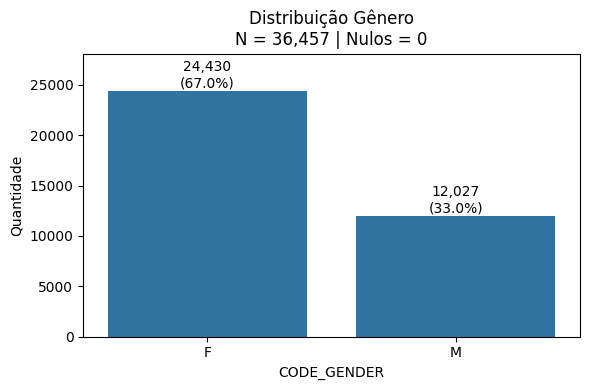

In [51]:
visualization.plot_binary(application_comum, 'CODE_GENDER', title='Distribuição Gênero')

A base apresenta maior concentração do público feminino (67%), indicando uma composição distinta da distribuição populacional global.

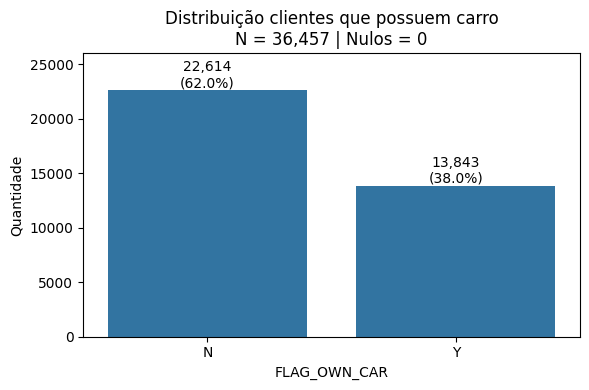

In [53]:
visualization.plot_binary(application_comum, 'FLAG_OWN_CAR', title='Distribuição clientes que possuem carro')

A distribuição de clientes que possuem carro apresenta leve assimetria.

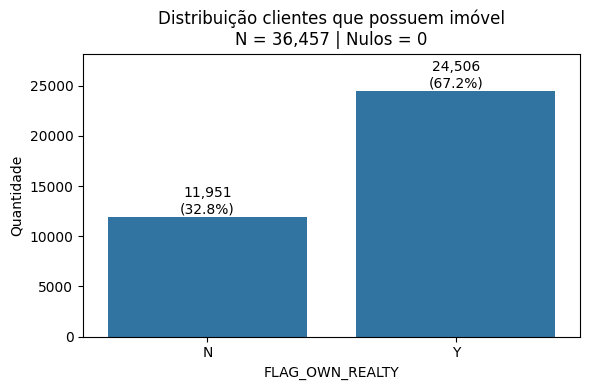

In [54]:
visualization.plot_binary(application_comum, 'FLAG_OWN_REALTY', title='Distribuição clientes que possuem imóvel')

A distribuição de clientes que possuem carro apresenta assimetria moderada para os que possuem, em contraponto a avaliação logo anterior dos que possuem carro.

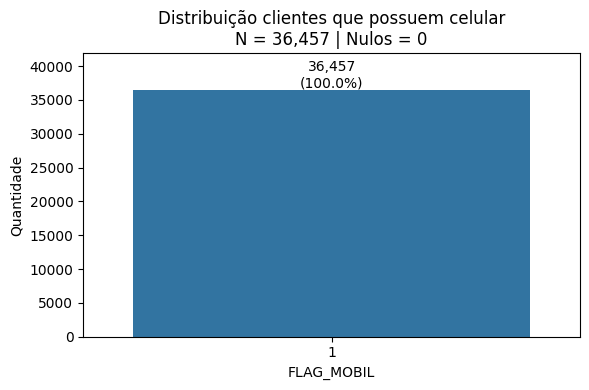

In [56]:
visualization.plot_binary(application_comum, 'FLAG_MOBIL', title='Distribuição clientes que possuem celular')

Decisão: Excluir variável por apresentar o mesmo valor para todos os registros

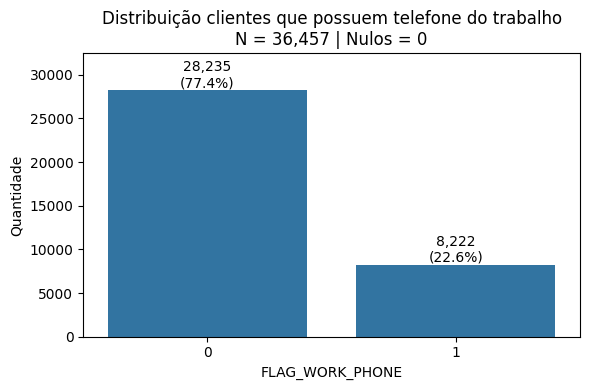

In [57]:
visualization.plot_binary(application_comum, 'FLAG_WORK_PHONE', title='Distribuição clientes que possuem telefone do trabalho')

A distribuição de telefone de trabalho apresenta elevada assimetria para não possuir.

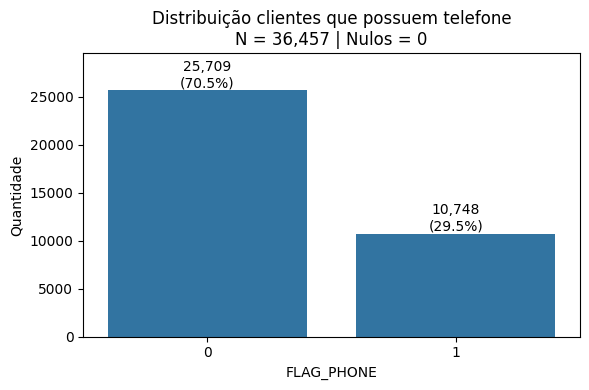

In [58]:
visualization.plot_binary(application_comum, 'FLAG_PHONE', title='Distribuição clientes que possuem telefone')

A distribuição de telefone apresenta elevada assimetria para não possuir.

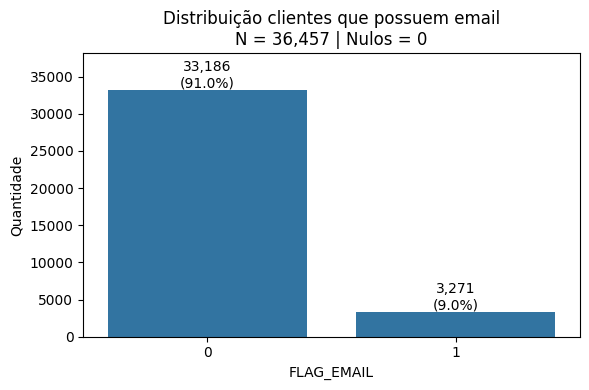

In [59]:
visualization.plot_binary(application_comum, 'FLAG_EMAIL', title='Distribuição clientes que possuem email')

A distribuição de email apresenta elevada assimetria para não possuir.

### 3.1 - application_comum: variáveis quantitativas

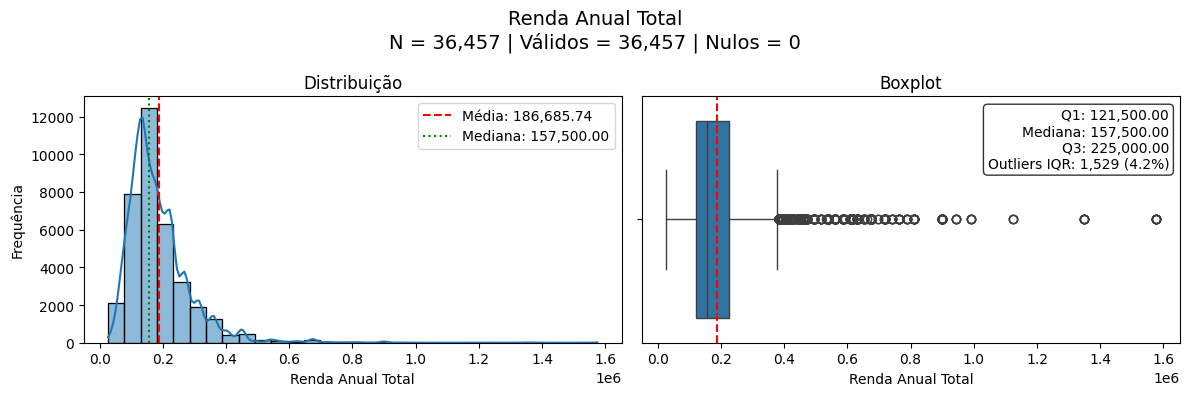

In [64]:
visualization.plot_numeric(application_comum, 'AMT_INCOME_TOTAL', title='Renda Anual Total')

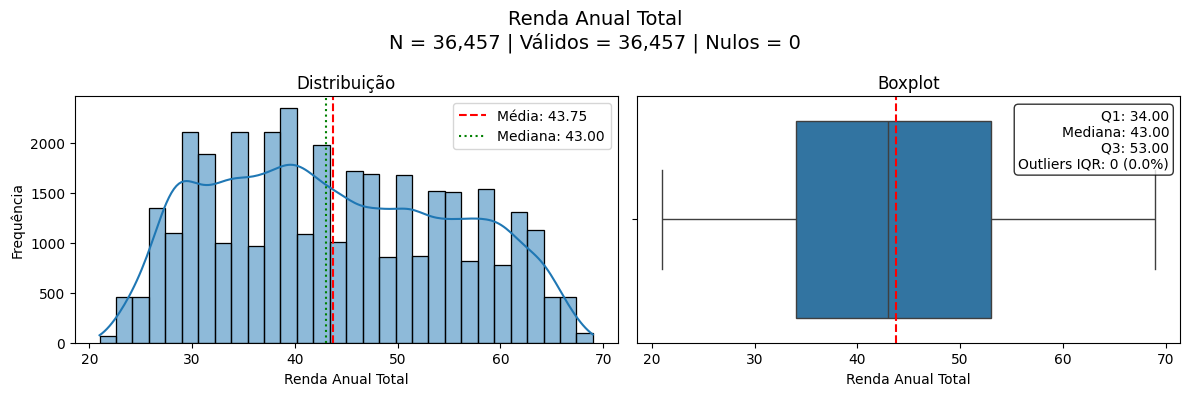

In [65]:
visualization.plot_numeric(application_comum, 'IDADE_ANOS', title='Renda Anual Total')

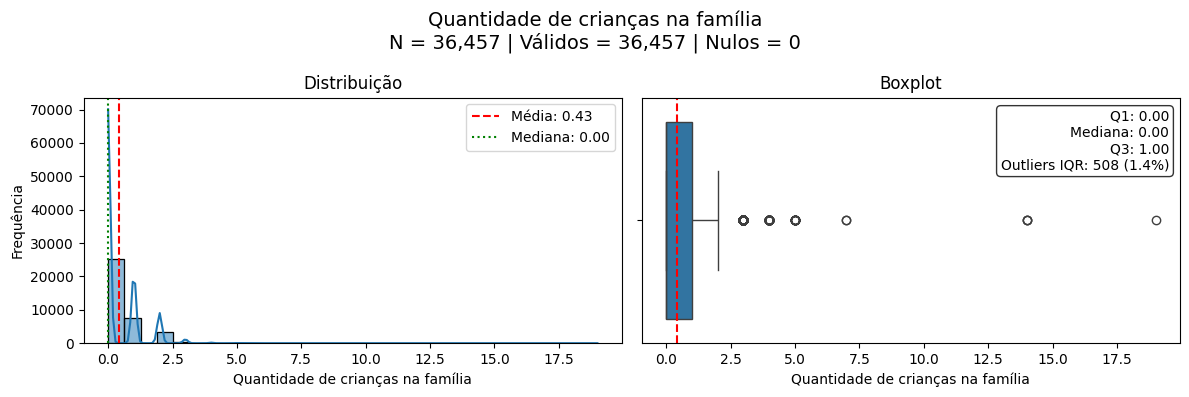

In [70]:
visualization.plot_numeric(application_comum, 'CNT_CHILDREN', title='Quantidade de crianças na família')

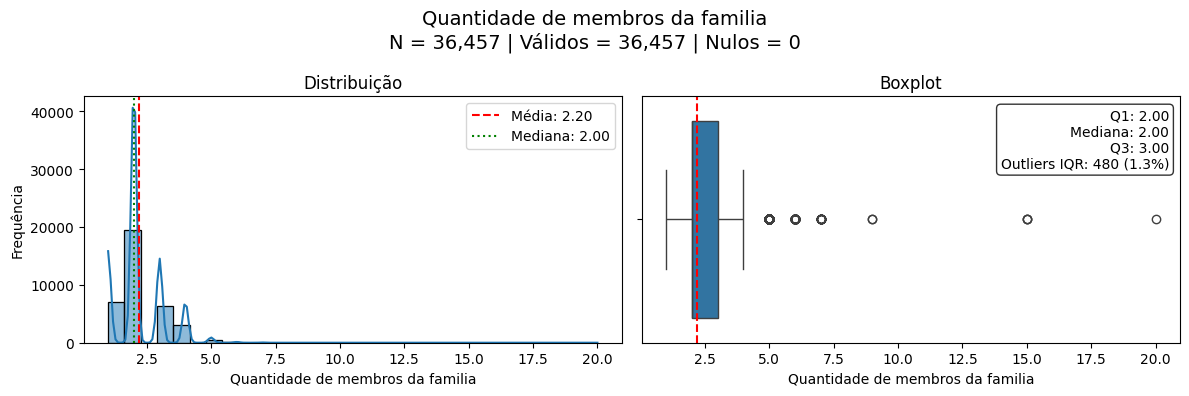

In [72]:
visualization.plot_numeric(application_comum, 'CNT_FAM_MEMBERS', title='Quantidade de membros da familia')

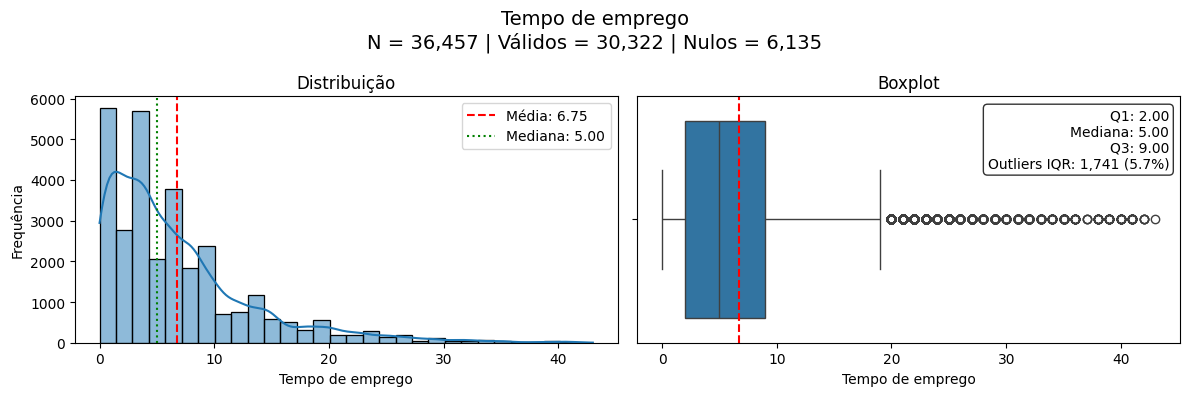

In [71]:
visualization.plot_numeric(application_comum, 'YEARS_EMPLOYED', title='Tempo de emprego')

In [ ]:
# histogramas / boxplots

## 3. Correlações

**Interpretação:** _comente cada correlação relevante, uma a uma._

In [ ]:
# heatmap de correlação

## 4. Outliers

**Interpretação:** _remover, winsorizar ou manter? Justifique._

In [ ]:
# detecção de outliers

## 5. Balanceamento de classes

**Interpretação:** _qual a proporção entre as classes e o que isso implica na escolha das métricas?_

In [ ]:
df[TARGET].value_counts(normalize=True)

## 6. Síntese da EDA

_Amarre os achados em uma narrativa única — é ela que vira o storytelling da apresentação._

In [68]:
application.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,438557.0,6022176.269842,571637.023257,5008804.0,5609375.0,6047745.0,6456971.0,7999952.0
CNT_CHILDREN,438557.0,0.42739,0.724882,0.0,0.0,0.0,1.0,19.0
AMT_INCOME_TOTAL,438557.0,187524.28601,110086.853066,26100.0,121500.0,160780.5,225000.0,6750000.0
DAYS_BIRTH,438557.0,-15997.904649,4185.030007,-25201.0,-19483.0,-15630.0,-12514.0,-7489.0
DAYS_EMPLOYED,438557.0,60563.675328,138767.799647,-17531.0,-3103.0,-1467.0,-371.0,365243.0
FLAG_MOBIL,438557.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0
FLAG_WORK_PHONE,438557.0,0.206133,0.404527,0.0,0.0,0.0,0.0,1.0
FLAG_PHONE,438557.0,0.287771,0.452724,0.0,0.0,0.0,1.0,1.0
FLAG_EMAIL,438557.0,0.108207,0.310642,0.0,0.0,0.0,0.0,1.0
CNT_FAM_MEMBERS,438557.0,2.194465,0.897207,1.0,2.0,2.0,3.0,20.0
